In [1]:
# Direct wrappers
#
# https://tslearn.readthedocs.io/en/latest/gen_modules/tslearn.clustering.html#module-tslearn.clustering
# https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.clustering.k_medoids.TimeSeriesKMedoids.html#sktime.clustering.k_medoids.TimeSeriesKMedoids


%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import random

# feature: addition of interpolation, smoothing and resolution selection
# feature: possibility to combine different clustering methods
# 
from timex.clustering import model_based_clustering # model-based clustering
from timex.clustering import distance_based_clustering # distance-based clustering
from timex.clustering import feature_based_clustering # feature-based clustering
from timex.clustering import meta_clustering # meta algorithms, to combine the different methods


from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score


c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.11\Lib\site-packages\tsfresh\__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
AKI_PATH = os.environ['AKI_PATH_NEW']
os.chdir(AKI_PATH)

ts_data = pd.read_parquet("data_preparation_DV_final_for_LCMM_19785AKIpatients_FU7-3650d_SW365d_TR90d_13032025.parquet")
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

TEST = True

In [3]:
# X = [n_ts, sz, dim]
# if there is no interpolation we assume that the time dimension is the second one
# i.e. we have at least 2 dimensions

ts_data = ts_data.rename(columns={"Time_since_index_AKI_days": "Time_days"})

In [4]:
ts_data = ts_data[['Time_days', 'eGFR_int', 'ID']]

In [5]:
if TEST:
    test_selection = random.choices(ts_data.ID.unique().tolist(), k=250)
else:
    test_selection = ts_data.ID.unique().tolist()

In [6]:
clusters_8_timexCustom_outwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=2000,
                                    direction='outwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:10<00:00, 236.35it/s, 31 steps of size 1.37e-01. acc. prob=0.90]


cl pos: 31
cl neg: 31
# series: 248, remaining: 186, RMSE_p: 0.1138472631573677, RMSE_n: 0.16199778020381927


\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\clustering\model_based_clustering.py:384: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remaining['series_idx'] = remaining[series_col].map(id_map)


Running LMM splitter..


...

cl pos: 31
cl neg: 31
# series: 186, remaining: 124, RMSE_p: 0.44920340180397034, RMSE_n: 0.5164496302604675
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:07<00:00, 353.47it/s, 7 steps of size 1.92e-01. acc. prob=0.87] 


cl pos: 31
Removing overlap: 2
cl neg: 29
# series: 124, remaining: 64, RMSE_p: 0.520024299621582, RMSE_n: 0.6236441731452942
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:04<00:00, 513.26it/s, 47 steps of size 1.09e-01. acc. prob=0.91]


cl pos: 31
Removing overlap: 9
cl neg: 22
# series: 64, remaining: 11, RMSE_p: 0.5337134003639221, RMSE_n: 0.4989982843399048
Assigned 8 clusters, assigning remaning 11 series to remainder clusters


In [7]:
[len(c) for c in clusters_8_timexCustom_outwards], sum([len(c) for c in clusters_8_timexCustom_outwards]), len(test_selection)

([31, 31, 31, 31, 31, 29, 31, 22, 11], 248, 250)

In [8]:
clusters_8_timexCustom_inwards = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                              'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=2000,
                                    direction='inwards',
                                    normalize=True)


Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:09<00:00, 268.64it/s, 31 steps of size 1.37e-01. acc. prob=0.90] 
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\clustering\model_based_clustering.py:384: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remaining['series_idx'] = remaining[series_col].map(id_map)


cl pos: 31
cl neg: 31
# series: 248, remaining: 186, RMSE_p: 0.7880613803863525, RMSE_n: 0.8635005950927734
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:06<00:00, 360.89it/s, 31 steps of size 1.53e-01. acc. prob=0.85]


cl pos: 31
Removing overlap: 10
cl neg: 21
# series: 186, remaining: 134, RMSE_p: 0.7156518697738647, RMSE_n: 0.8581864833831787
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:05<00:00, 423.24it/s, 15 steps of size 3.11e-01. acc. prob=0.87]


cl pos: 31
Removing overlap: 15
cl neg: 16
# series: 134, remaining: 87, RMSE_p: 0.6237736344337463, RMSE_n: 0.7697499394416809
Running LMM splitter..


sample: 100%|██████████| 2500/2500 [00:05<00:00, 432.68it/s, 15 steps of size 2.92e-01. acc. prob=0.90]


cl pos: 31
Removing overlap: 13
cl neg: 18
# series: 87, remaining: 38, RMSE_p: 0.5112898945808411, RMSE_n: 0.6551539897918701
Assigned 8 clusters, assigning remaning 38 series to remainder clusters


In [9]:
[len(c) for c in clusters_8_timexCustom_inwards], sum([len(c) for c in clusters_8_timexCustom_inwards]), len(test_selection)

([31, 31, 31, 21, 31, 16, 31, 18, 38], 248, 250)

In [ ]:
clusters_8_mm_slope = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='slope',
                                    num_samples=2000,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:15<00:00, 129.21it/s, 31 steps of size 1.31e-01. acc. prob=0.87]


(248, 6)


In [11]:
[len(c) for c in clusters_8_mm_slope], sum([len(c) for c in clusters_8_mm_slope]), len(test_selection)

([78, 13, 81, 22, 22, 7, 18, 7], 248, 250)

In [12]:
clusters_8_mm_rec = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_effect_clustering',
                                    num_samples=2000,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2500/2500 [00:16<00:00, 151.24it/s, 31 steps of size 1.32e-01. acc. prob=0.87]


In [13]:
[len(c) for c in clusters_8_mm_rec], sum([len(c) for c in clusters_8_mm_rec]), len(test_selection)

([61, 27, 5, 24, 16, 80, 19, 16], 248, 250)

In [ ]:
clusters_8_mm_ric = model_based_clustering.clustering_mm(ts_data.loc[ts_data.ID.isin(test_selection)], 
                                                                            'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    how='random_intercept_clustering',
                                    num_samples=2000,
                                    num_warmup=500,
                                    normalize=True)

sample: 100%|██████████| 2000/2000 [00:05<00:00, 335.89it/s, 15 steps of size 2.72e-01. acc. prob=0.90]


In [15]:
clusters_8_lmm = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=8, 
                                    spline_degree=4, 
                                    num_samples=2000,
                                    num_warmup=500,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    num_chains=1,
                                    vi = False,
                                    tau = 10,
                                    normalize=True, 
                                    adaptive_spline=True)

Characteristics of B_obs
min max cond#
0.0 1.0 97.621994
Defining kernel...
Init sampler...
Start sampler...


sample: 100%|██████████| 2500/2500 [01:35<00:00, 26.08it/s, 63 steps of size 5.98e-02. acc. prob=0.92]  


Start posterior draws...


In [16]:
[len(c) for c in clusters_8_lmm]

[2, 63, 27, 28, 34, 30, 37, 27]

In [56]:
clusters_8_lmm_vi = model_based_clustering.clustering_lmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=8, 
                                    spline_degree=4, 
                                    num_steps=5000,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    vi = True,
                                    tau_search = False,
                                    tau = 100,
                                    normalize=True, 
                                    adaptive_spline=True)

100%|██████████| 5000/5000 [00:08<00:00, 595.92it/s, init loss: 67112.9141, avg. loss [4751-5000]: 6909.5981]


(500, 248, 8)


In [57]:
[len(c) for c in clusters_8_lmm_vi]

[30, 32, 27, 26, 51, 11, 27, 44]

In [19]:
sum([len(c) for c in clusters_8_mm_slope])

248

In [58]:
LOL = { 'lmm_vi': [i for i,c in enumerate(clusters_8_lmm_vi) for _c in c],
        'lmm':[i for i,c in enumerate(clusters_8_lmm) for _c in c],
        'mm_ric':[i for i,c in enumerate(clusters_8_mm_ric) for _c in c],
        'mm_rec':[i for i,c in enumerate(clusters_8_mm_rec) for _c in c], 
        'mm_slope':[i for i,c in enumerate(clusters_8_mm_slope) for _c in c],    
        'mm_inw':[i for i,c in enumerate(clusters_8_timexCustom_inwards) for _c in c], 
        'mm_out':[i for i,c in enumerate(clusters_8_timexCustom_outwards) for _c in c]
}

# get stats
res = []
for k,v1 in LOL.items():
    for l,v2 in LOL.items():
        res.append({
            'm1': k,
            'm2': l, 
            'ami': adjusted_mutual_info_score(v1,v2), 
            'ari': adjusted_rand_score(v1,v2)
            }) 
        


In [59]:
ami_cm = pd.DataFrame(res).pivot(index='m1', columns='m2', values='ami')
ari_cm = pd.DataFrame(res).pivot(index='m1', columns='m2', values='ari')

<Axes: xlabel='m2', ylabel='m1'>

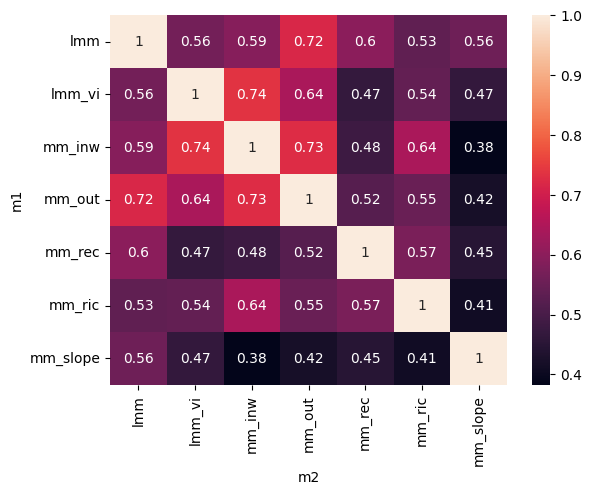

In [60]:
# add heatmap
sns.heatmap(ari_cm, annot=True)

<Axes: xlabel='m2', ylabel='m1'>

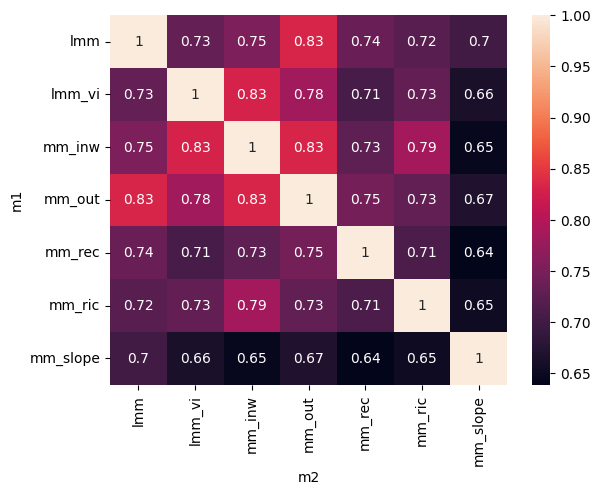

In [61]:
# add heatmap
sns.heatmap(ami_cm, annot=True)

In [62]:
res_list = []
for clnum, idlist in enumerate(clusters_8_timexCustom_outwards):
    for id in idlist:
        res_list.append({
            'clusters_8_lmm': clnum, 
            'ID': id
        })

ts_data = pd.merge(ts_data, pd.DataFrame(res_list), how='left', on='ID')


In [63]:
ts_data = ts_data.fillna(-1)

<Axes: xlabel='Time_days', ylabel='eGFR_int'>

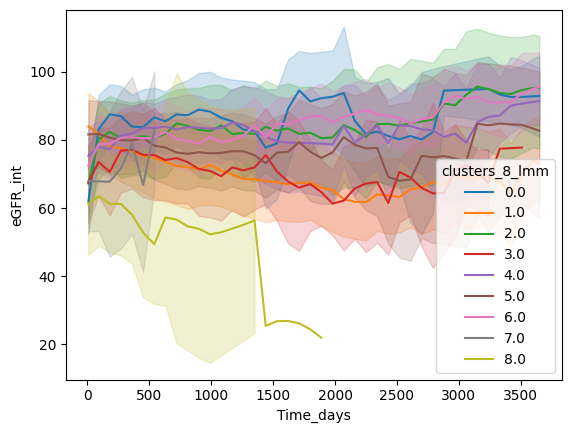

In [64]:
sns.lineplot(ts_data[ts_data.ID.isin(test_selection)], x='Time_days', y='eGFR_int', 
             hue='clusters_8_lmm', palette='tab10')